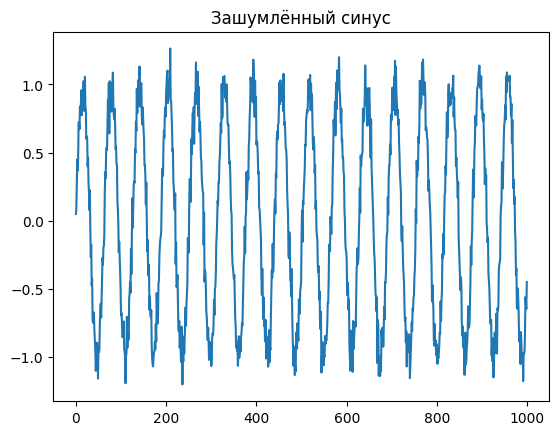

In [18]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, Dense
from tensorflow.keras.optimizers import Adam

#сгенерируем зашумленный синус
np.random.seed(42)

t = np.linspace(0, 100, 1000) #массив из 1000 числел от 0 до 100
signal = np.sin(t) #в каждой точке вичисляем значение
noise = 0.1 * np.random.randn(len(t)) #создаем шум с помощью случайных чисел с нормальным распределением(уменьшаем амплитуду *0.1)

data = signal + noise

#выведем то что получили
plt.plot(data)
plt.title("Зашумлённый синус")
plt.show()

Подготовим данные, будем предсказывать новую точку на основе предыдущих 20

In [19]:
def create_dataset(series, window_size=20):
    X, y = [], []
    for i in range(len(series) - window_size):
        X.append(series[i:i+window_size]) #20 значений
        y.append(series[i+window_size]) #следующие 20 значений
    return np.array(X), np.array(y)

X, y = create_dataset(data, window_size=20)

#добавляем размерность признаков
X = X[..., np.newaxis]

#разделим на тестовую и тренировочную выборки
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

RNN модель

In [20]:
rnn_model = Sequential([
    SimpleRNN(32, input_shape=(20, 1)), #20 временных шагов, 1 признак
    Dense(1) #выходной слой
])

rnn_model.compile(
    optimizer=Adam(learning_rate=0.001), #оптимизатор Adam (для изменения веса)
    loss="mse" #минимизируем среднеквадратичную ошибку
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


обучение RNN

In [21]:
rnn_history = rnn_model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1 #для вывода прогресса обучения
)

Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.3912 - val_loss: 0.0347
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0400 - val_loss: 0.0226
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0238 - val_loss: 0.0177
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0186 - val_loss: 0.0158
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0159 - val_loss: 0.0152
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0160 - val_loss: 0.0146
Epoch 7/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0142 - val_loss: 0.0136
Epoch 8/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0148 - val_loss: 0.0130
Epoch 9/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0121 - val_loss: 0.0128
Epoch 10/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0124 - val_loss: 0.0127
Epoch 11/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0131 - val_loss: 0.0125
Epoch 12/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0

LSTM модель

In [22]:
lstm_model = Sequential([
    LSTM(32, input_shape=(20, 1)),
    Dense(1)
])

lstm_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mse"
)

обучение LSTM

In [23]:
lstm_history = lstm_model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.4532 - val_loss: 0.2531
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.2049 - val_loss: 0.1121
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0737 - val_loss: 0.0154
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0163 - val_loss: 0.0126
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0124 - val_loss: 0.0125
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0119 - val_loss: 0.0123
Epoch 7/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0121 - val_loss: 0.0122
Epoch 8/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0131 - val_loss: 0.0122
Epoch 9/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0117 - val_loss: 0.0120
Epoch 10/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0117 - val_loss: 0.0118
Epoch 11/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0115 - val_loss: 0.0119
Epoch 12/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0

сравним точности RNN и LSTM (через среднюю квадратичную ошибку MSE)

In [24]:
rnn_mse = rnn_model.evaluate(X_test, y_test, verbose=0)
lstm_mse = lstm_model.evaluate(X_test, y_test, verbose=0)

print(f"RNN MSE:  {rnn_mse:.5f}")
print(f"LSTM MSE: {lstm_mse:.5f}")

RNN MSE:  0.01091
LSTM MSE: 0.01102


теперь сравним визуально

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step


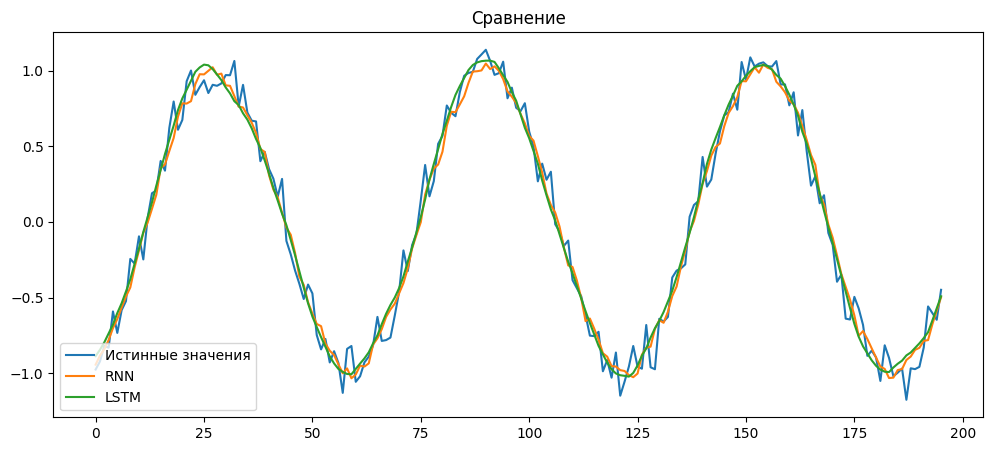

In [25]:
rnn_pred = rnn_model.predict(X_test)
lstm_pred = lstm_model.predict(X_test)

plt.figure(figsize=(12,5))
plt.plot(y_test, label="Истинные значения")
plt.plot(rnn_pred, label="RNN")
plt.plot(lstm_pred, label="LSTM")
plt.legend()
plt.title("Сравнение")
plt.show()

обе модели хорошо восстанавливают истинные значения на основе зашумленных, но LSTM показывает более точный результат